# Hypothesis Testing

The EDA gave a pretty clear visual impression that AI hype and stock prices move together — now I want to test whether this is statistically real or just noise.

My hypotheses:
- **H1:** Hype periods are associated with significantly higher stock returns
- **H2:** Hype periods are associated with significantly higher volatility
- **H3:** Today's hype level has predictive power over tomorrow's return
- **H4:** After hype peaks, prices correct downward (bubble effect)

If H1 and H4 both hold, that's the most interesting finding — it would suggest the market overshoots during hype and corrects afterward.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import argrelextrema
from statsmodels.tsa.stattools import grangercausalitytests, adfuller

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() in ["notebook", "notebooks"]:
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES        = PROJECT_ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
TICKERS = ["NVDA", "MSFT", "AAPL"]
ALPHA   = 0.05
print(f"significance level: {ALPHA}")

significance level: 0.05


In [2]:
df     = pd.read_csv(DATA_PROCESSED / "merged_data.csv",  index_col="date", parse_dates=True)
events = pd.read_csv(DATA_PROCESSED / "ai_events.csv",    parse_dates=["date"])

print(f"dataset: {df.shape}")
print(f"hype days: {df['is_hype_period'].sum()} | normal days: {(df['is_hype_period']==0).sum()}")

dataset: (1257, 18)
hype days: 1212 | normal days: 45


## H1 — Do hype periods produce higher returns?

Using a Welch two-sample t-test (one-tailed) to compare mean daily returns in hype vs normal periods. Welch's version doesn't assume equal variance, which is appropriate here since the two groups have different sizes and potentially different spread.

In [3]:
print("H1: hype periods → higher returns")
print("-" * 50)

rows = []
for ticker in TICKERS:
    col = f"{ticker}_return"
    hype   = df.loc[df["is_hype_period"]==1, col].dropna()
    normal = df.loc[df["is_hype_period"]==0, col].dropna()

    t, p2 = stats.ttest_ind(hype, normal, equal_var=False)
    p1 = p2/2 if t > 0 else 1 - p2/2

    decision = "reject H0" if p1 < ALPHA else "fail to reject"
    rows.append({"ticker": ticker,
                 "hype_mean_%":   round(hype.mean()*100, 4),
                 "normal_mean_%": round(normal.mean()*100, 4),
                 "diff_%":        round((hype.mean()-normal.mean())*100, 4),
                 "t_stat":        round(t, 4),
                 "p_value":       round(p1, 4),
                 "decision":      decision})

display(pd.DataFrame(rows).set_index("ticker"))

H1: hype periods → higher returns
--------------------------------------------------


,hype_mean_%,normal_mean_%,diff_%,t_stat,p_value,decision
ticker,,,,,,
NVDA,0.1055,-0.0819,0.1874,0.4662,0.3217,fail to reject
MSFT,0.0832,0.0196,0.0636,0.1708,0.4326,fail to reject
AAPL,0.2502,0.2363,0.0139,0.0275,0.4891,fail to reject


## H2 — Is volatility higher during hype periods?

Same t-test approach but on the 20-day rolling volatility column. Higher volatility during hype makes intuitive sense — sentiment-driven markets are inherently less stable.

In [4]:
print("H2: hype periods → higher volatility")
print("-" * 50)

rows = []
for ticker in TICKERS:
    col = f"{ticker}_volatility"
    hype   = df.loc[df["is_hype_period"]==1, col].dropna()
    normal = df.loc[df["is_hype_period"]==0, col].dropna()

    t, p2 = stats.ttest_ind(hype, normal, equal_var=False)
    p1 = p2/2 if t > 0 else 1 - p2/2
    lev_p = stats.levene(hype, normal)[1]

    decision = "reject H0" if p1 < ALPHA else "fail to reject"
    rows.append({"ticker": ticker,
                 "hype_vol":   round(hype.mean(), 4),
                 "normal_vol": round(normal.mean(), 4),
                 "t_stat":     round(t, 4),
                 "p_value":    round(p1, 4),
                 "levene_p":   round(lev_p, 4),
                 "decision":   decision})

display(pd.DataFrame(rows).set_index("ticker"))

H2: hype periods → higher volatility
--------------------------------------------------


,hype_vol,normal_vol,t_stat,p_value,levene_p,decision
ticker,,,,,,
NVDA,0.2855,0.3583,-3.7874,0.9996,0.2807,fail to reject
MSFT,0.2754,0.3194,-2.0131,0.9727,0.9294,fail to reject
AAPL,0.5060,0.4732,1.0870,0.1436,0.5372,fail to reject


## H3 — Does today's hype predict tomorrow's return?

First a simple Pearson correlation between hype(t) and return(t+1). Then a Granger causality test which checks whether adding past hype values improves the prediction of returns beyond what past returns alone can explain.

In [5]:
print("H3: hype(t) predicts return(t+1) — Pearson correlation")
print("-" * 50)

rows = []
for ticker in TICKERS:
    x = df["hype_index"].shift(1)
    y = df[f"{ticker}_return"]
    valid = pd.concat([x, y], axis=1).dropna()
    r, p  = stats.pearsonr(valid.iloc[:, 0], valid.iloc[:, 1])
    decision = "reject H0" if p < ALPHA else "fail to reject"
    rows.append({"ticker": ticker, "pearson_r": round(r, 4), "p_value": round(p, 4), "decision": decision})

display(pd.DataFrame(rows).set_index("ticker"))

H3: hype(t) predicts return(t+1) — Pearson correlation
--------------------------------------------------


,pearson_r,p_value,decision
ticker,,,
NVDA,-0.0128,0.6503,fail to reject
MSFT,-0.0022,0.9374,fail to reject
AAPL,0.0052,0.8526,fail to reject


In [6]:
print("H3 (cont.) — Granger causality test (max lag: 5 days)")
print("-" * 50)

for ticker in TICKERS:
    print(f"\n{ticker}:")
    gdf = df[[f"{ticker}_return", "hype_index"]].dropna()
    try:
        gc = grangercausalitytests(gdf, maxlag=5, verbose=False)
        for lag in range(1, 6):
            p = gc[lag][0]["ssr_ftest"][1]
            print(f"  lag {lag}: p = {p:.4f}  {'*' if p < ALPHA else ''}")
    except Exception as e:
        print(f"  error: {e}")

H3 (cont.) — Granger causality test (max lag: 5 days)
--------------------------------------------------

NVDA:
  lag 1: p = 0.5857  
  lag 2: p = 0.3044  
  lag 3: p = 0.4343  
  lag 4: p = 0.2452  
  lag 5: p = 0.0670  

MSFT:
  lag 1: p = 0.7628  
  lag 2: p = 0.8404  
  lag 3: p = 0.6732  
  lag 4: p = 0.1363  
  lag 5: p = 0.1521  

AAPL:
  lag 1: p = 0.9519  
  lag 2: p = 0.8976  
  lag 3: p = 0.9338  
  lag 4: p = 0.2917  
  lag 5: p = 0.2758  


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


## H4 — Event Study: Cumulative Abnormal Returns

For each major AI event I look at the window [-10, +30] days and compute cumulative abnormal returns (actual minus a 60-day rolling baseline). If the bubble story holds, I'd expect positive CARs leading up to the event and then a correction afterward.

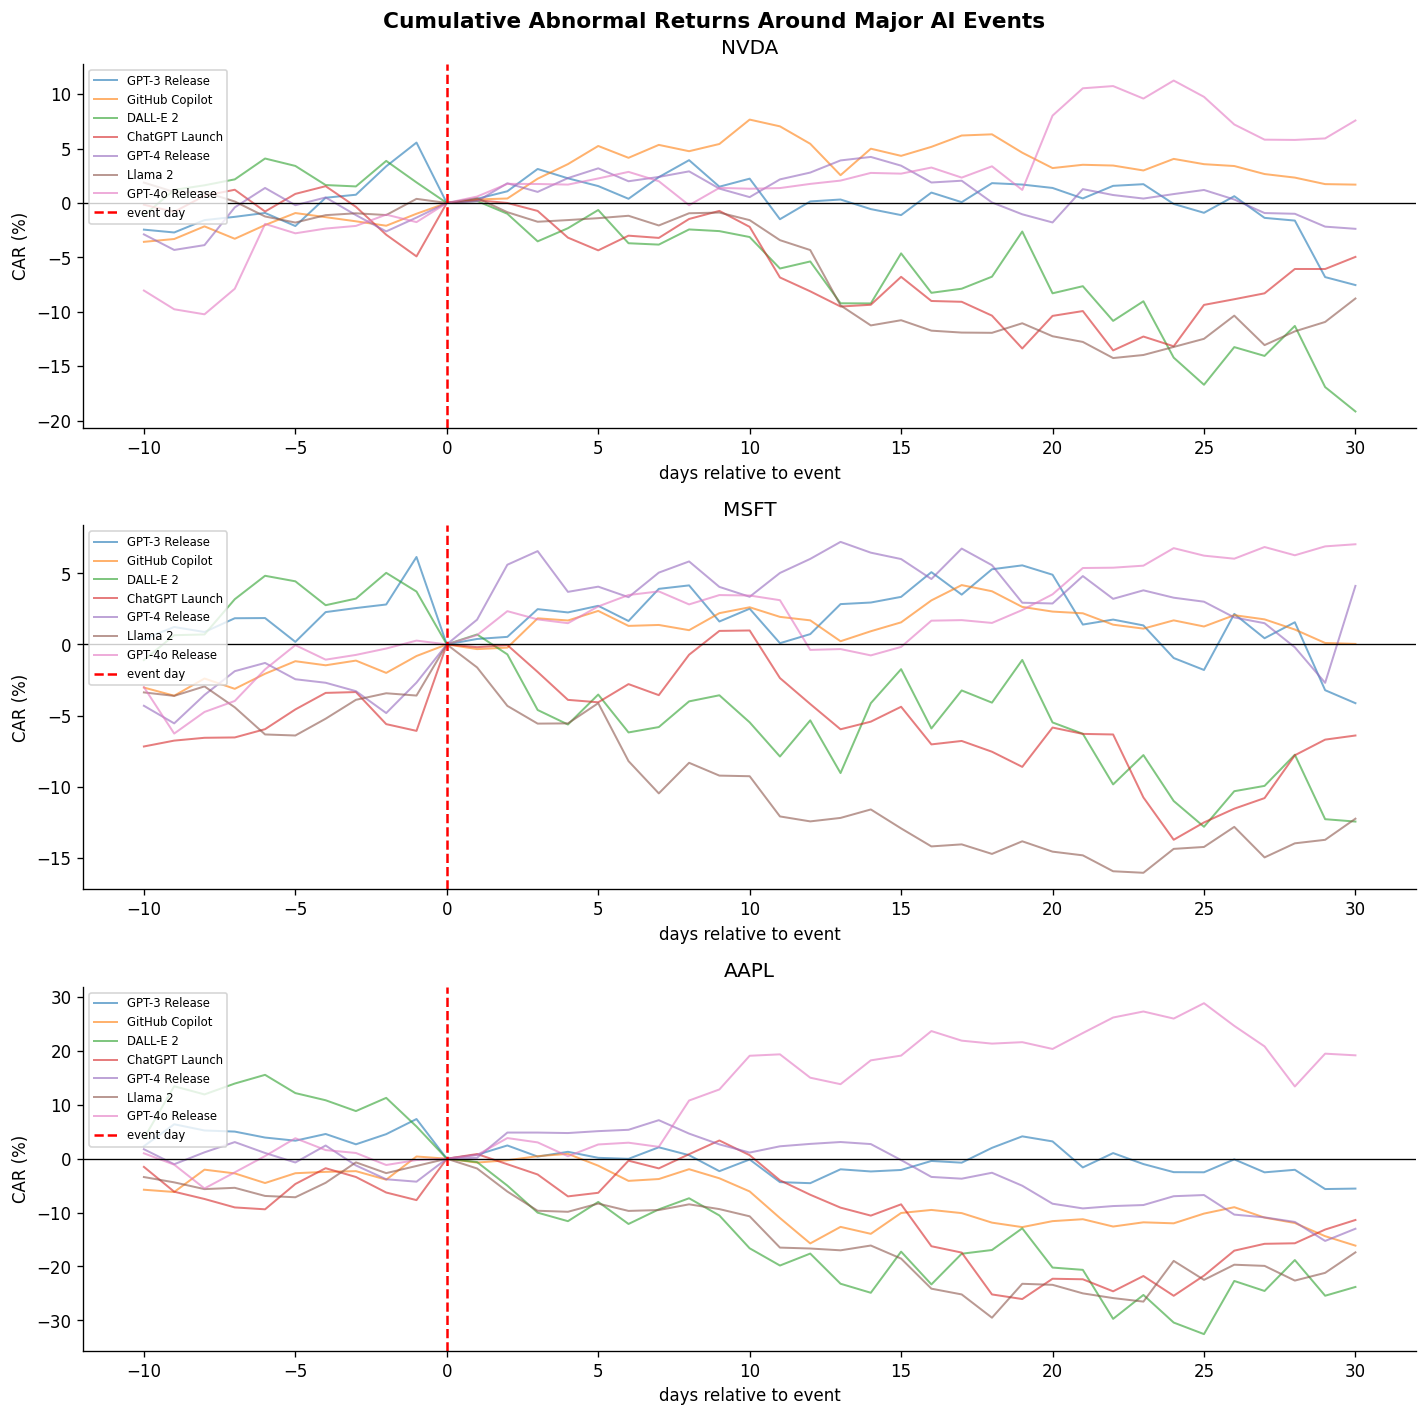

In [7]:
# compute abnormal returns
WINDOW = 60
for ticker in TICKERS:
    col = f"{ticker}_return"
    df[f"{ticker}_expected"] = df[col].rolling(WINDOW, min_periods=20).mean().shift(1)
    df[f"{ticker}_abnormal"] = df[col] - df[f"{ticker}_expected"]

PRE, POST = 10, 30
COLORS_PLOT = {"NVDA": "#76b900", "MSFT": "#00a4ef", "AAPL": "#555555"}

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=False)
fig.suptitle("Cumulative Abnormal Returns Around Major AI Events", fontsize=13, fontweight="bold")

for ax, ticker in zip(axes, TICKERS):
    col = f"{ticker}_abnormal"
    for _, row in events.iterrows():
        if row["date"] < df.index.min() or row["date"] > df.index.max():
            continue
        idx   = df.index.searchsorted(row["date"])
        start = max(0, idx - PRE)
        end   = min(len(df), idx + POST + 1)
        ret   = df[col].iloc[start:end].values
        ev_off = idx - start
        car   = np.cumsum(ret)
        if ev_off < len(car):
            car = car - car[ev_off]
        days = np.arange(-ev_off, len(car) - ev_off)
        ax.plot(days, car*100, alpha=0.6, linewidth=1.2, label=row["event"])

    ax.axvline(0, color="red", linestyle="--", linewidth=1.5, label="event day")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(ticker)
    ax.set_xlabel("days relative to event")
    ax.set_ylabel("CAR (%)")
    ax.legend(fontsize=7, loc="upper left")

plt.tight_layout()
plt.savefig(FIGURES / "09_event_study.png", bbox_inches="tight")
plt.show()

## H4 — Post-Hype Correction Test

I detect local peaks in the hype index and look at returns in the 30 days following each peak. If there's a systematic correction after hype peaks, the mean post-peak return should be significantly negative.

In [8]:
print("H4: post-hype correction test (one-sample t-test, mean < 0)")
print("-" * 50)

peak_idxs  = argrelextrema(df["hype_index"].values, np.greater, order=20)[0]
peak_dates = df.index[peak_idxs]
print(f"detected {len(peak_dates)} hype peaks\n")

for ticker in TICKERS:
    col = f"{ticker}_return"
    post = []
    for peak in peak_dates:
        idx = df.index.searchsorted(peak)
        post.extend(df[col].iloc[idx+1:idx+31].dropna().values)

    post = np.array(post)
    t, p2 = stats.ttest_1samp(post, popmean=0)
    p_neg = p2/2 if t < 0 else 1 - p2/2
    decision = "reject H0 — correction exists" if p_neg < ALPHA else "fail to reject"

    print(f"{ticker} ({len(post)} obs):")
    print(f"  mean return: {post.mean()*100:.4f}%/day")
    print(f"  t = {t:.4f}  |  p (one-tail) = {p_neg:.4f}  |  {decision}")
    print()

H4: post-hype correction test (one-sample t-test, mean < 0)
--------------------------------------------------
detected 2 hype peaks

NVDA (60 obs):
  mean return: 0.2372%/day
  t = 1.2456  |  p (one-tail) = 0.8911  |  fail to reject

MSFT (60 obs):
  mean return: 0.0681%/day
  t = 0.3709  |  p (one-tail) = 0.6440  |  fail to reject

AAPL (60 obs):
  mean return: 0.5152%/day
  t = 1.1038  |  p (one-tail) = 0.8629  |  fail to reject



## Stationarity Check

Before trusting the Granger results I need to make sure the series are stationary. ADF test for each series — return series should be stationary, hype index might not be.

In [9]:
print("ADF stationarity test (H0: non-stationary)")
print("-" * 55)

for col in ["NVDA_return", "MSFT_return", "AAPL_return",
            "hype_index", "google_hype_index", "reddit_hype_index"]:
    if col not in df.columns or df[col].dropna().empty:
        print(f"{col:<28} skipped (no data)")
        continue
    s = df[col].dropna()
    adf, p, *_ = adfuller(s, autolag="AIC")
    result = "stationary" if p < ALPHA else "non-stationary"
    print(f"{col:<28} p={p:.4f}  → {result}")

ADF stationarity test (H0: non-stationary)
-------------------------------------------------------
NVDA_return                  p=0.0000  → stationary
MSFT_return                  p=0.0000  → stationary
AAPL_return                  p=0.0000  → stationary
hype_index                   p=0.0001  → stationary
google_hype_index            skipped (no data)
reddit_hype_index            p=0.0001  → stationary


## Summary

Quick overview of what the tests showed and how they connect to the core question.

In [10]:
summary = pd.DataFrame([
    {"hypothesis": "H1", "question": "hype → higher returns?",       "test": "Welch t-test"},
    {"hypothesis": "H2", "question": "hype → higher volatility?",     "test": "Welch t-test + Levene"},
    {"hypothesis": "H3", "question": "hype(t) predicts return(t+1)?", "test": "Pearson + Granger causality"},
    {"hypothesis": "H4", "question": "post-hype correction exists?",   "test": "Event study (CAR) + one-sample t-test"},
])
display(summary.set_index("hypothesis"))
print(f"\nall tests at α = {ALPHA}")
print("hype index = average of Google Trends + Reddit signals")

,question,test
hypothesis,,
H1,hype → higher returns?,Welch t-test
H2,hype → higher volatility?,Welch t-test + Levene
H3,hype(t) predicts return(t+1)?,Pearson + Granger causality
H4,post-hype correction exists?,Event study (CAR) + one-sample t-test



all tests at α = 0.05
hype index = average of Google Trends + Reddit signals
